# Credit Card Fraud Detection - EDA

284,807 transactions · 0.17% fraud · 30 features (V1–V28 PCA + Amount + Time)

Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [1]:
from pathlib import Path
from scipy import stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent

df = pd.read_csv(f'{project_root}/data/raw/creditcard.csv')

print('Dataframe shape:', df.shape)
df.head(10)

Dataframe shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 1. Class imbalance

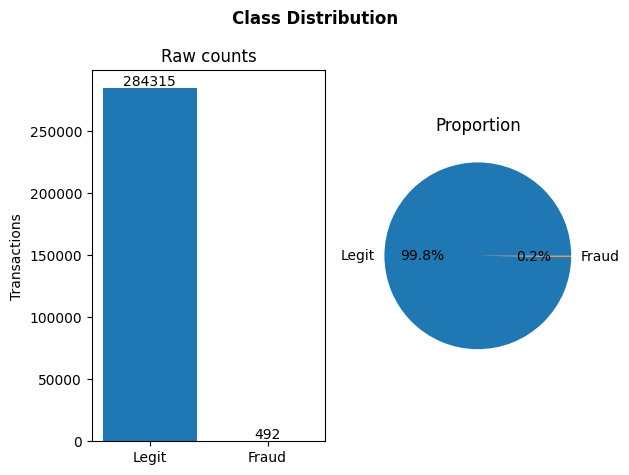

fraud_rate: 0.173%


In [3]:
counts = df['Class'].value_counts()

fig, axes =  plt.subplots(1, 2)
fig.suptitle('Class Distribution', fontweight='bold')

axes[0].bar(['Legit', 'Fraud'], counts.values)
axes[0].set_title('Raw counts')
axes[0].set_ylabel('Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2000, v, ha='center')


axes[1].pie(counts, labels=['Legit', 'Fraud'], autopct='%1.1f%%')
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

fraud_rate = (df['Class'] == 1).sum() / len(df['Class']) * 100
print(f'fraud_rate: {fraud_rate:.3f}%')

## 2. Amount distribution - fraud vs legit

Legit  — mean: $88.29  median: $22.00  max: $25691.16
Fraud  — mean: $122.21  median: $9.25  max: $2125.87


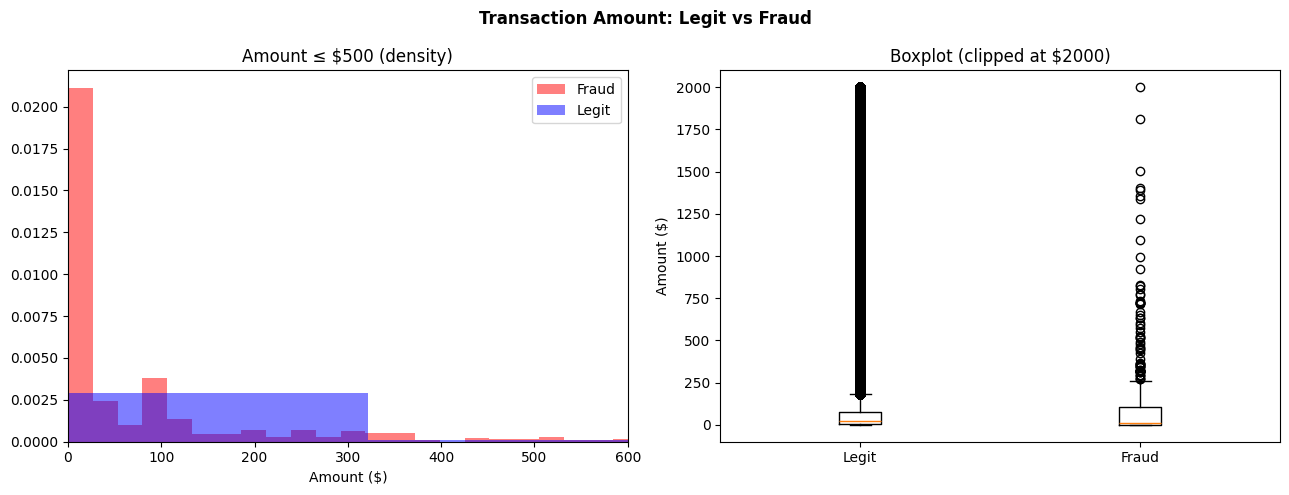

In [4]:
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

print(f'Legit  — mean: ${legit.mean():.2f}  median: ${legit.median():.2f}  max: ${legit.max():.2f}')
print(f'Fraud  — mean: ${fraud.mean():.2f}  median: ${fraud.median():.2f}  max: ${fraud.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Transaction Amount: Legit vs Fraud', fontweight='bold')

axes[0].hist(fraud, bins=80, color='red', alpha=0.5, density=True, label='Fraud')
axes[0].hist(legit, bins=80, color='blue', alpha=0.5, density=True, label='Legit')
axes[0].set_xlim(0, 600)
axes[0].set_title('Amount ≤ $500 (density)')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

axes[1].boxplot([legit.clip(0, 2000), fraud.clip(0, 2000)],
                tick_labels=['Legit', 'Fraud']
                )
axes[1].set_title('Boxplot (clipped at $2000)')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

## 3. Which PCA features separate fraud best?

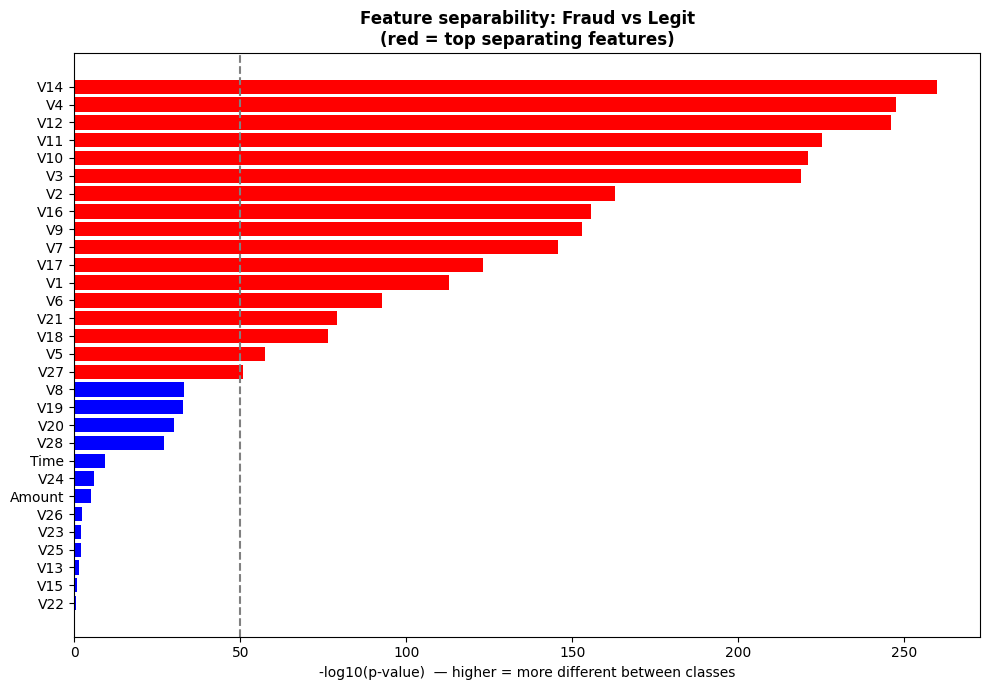

In [5]:
pca_features = [f'V{i}' for i in range (1,29)] + ['Time', 'Amount']

# Mann-Whitney U test
# High statistic = distributions are very different between classes
separability = {}
for col in pca_features:
    stat, p = stats.mannwhitneyu(
        df[df['Class']==0][col],
        df[df['Class']==1][col],
        alternative='two-sided'
    )
    separability[col] = -np.log10(p + 1e-300)  # higher = more separable


sep_df = pd.DataFrame.from_dict(separability, orient='index', columns=['neg_log_p'])
sep_df = sep_df.sort_values('neg_log_p', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['red' if v > 50 else 'blue' for v in sep_df['neg_log_p']]
ax.barh(sep_df.index, sep_df['neg_log_p'], color=colors)
ax.set_xlabel('-log10(p-value)  — higher = more different between classes')
ax.set_title('Feature separability: Fraud vs Legit\n(red = top separating features)', fontweight='bold')
ax.axvline(50, color='grey', linestyle='--')

plt.tight_layout()
plt.show()


## 4. Top feature distributions - fraud vs legit

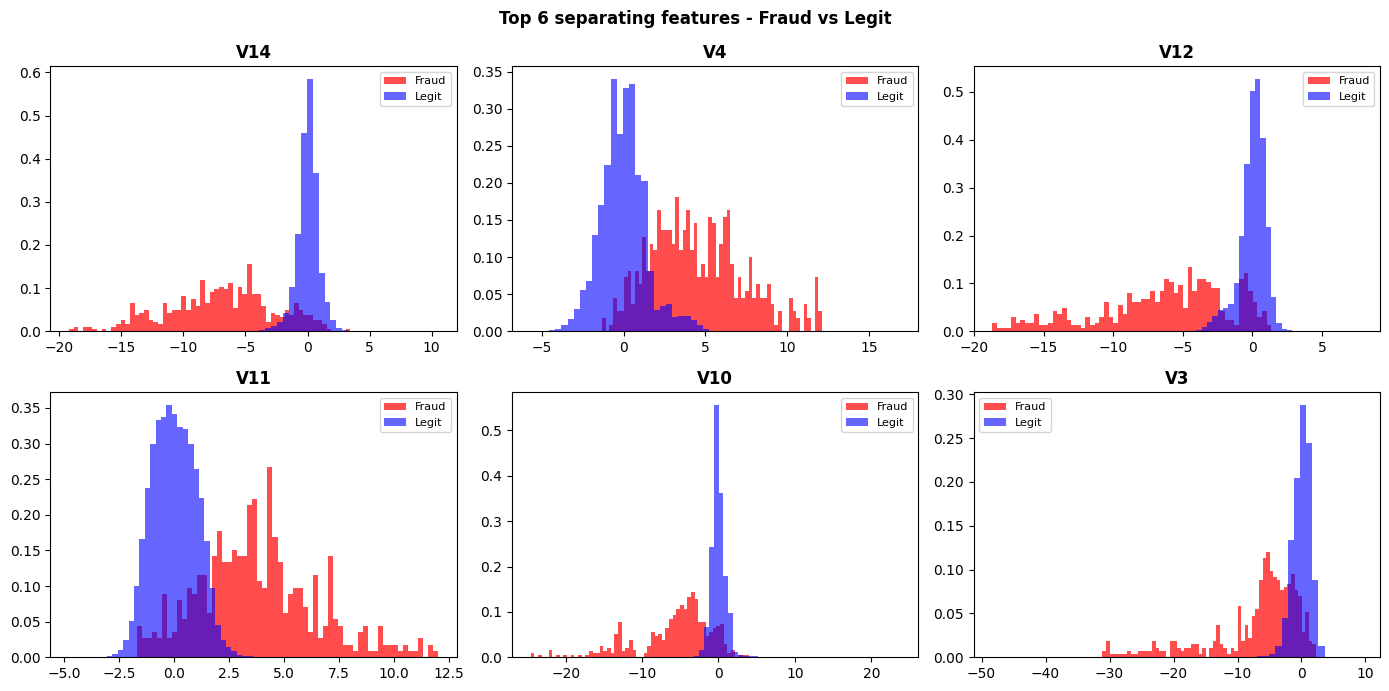

In [6]:
top_features = sep_df.sort_values('neg_log_p', ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Top 6 separating features - Fraud vs Legit', fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    ax.hist(df[df['Class']==1][feat], bins=60, alpha=0.7,
            color='red', label='Fraud', density=True)
    ax.hist(df[df['Class']==0][feat], bins=60, alpha=0.6,
            color='blue', label='Legit', density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Time of transaction


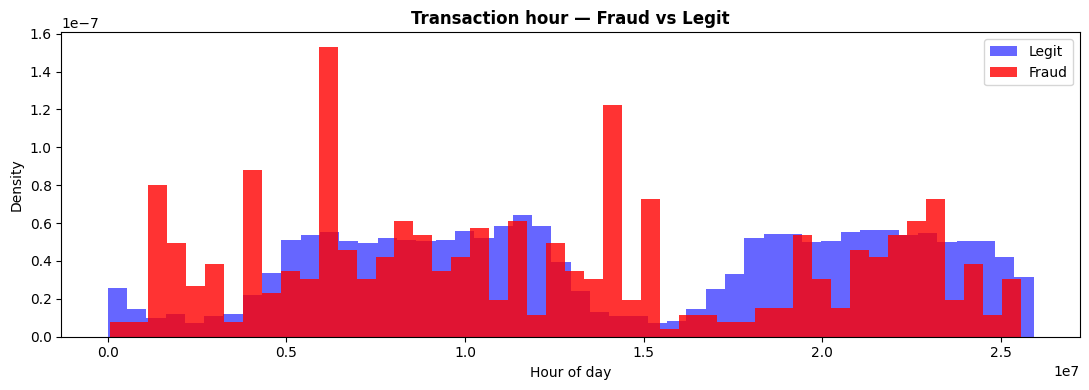

In [7]:
df['Hour'] = (df['Time']*3600) / 24

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(df[df['Class']==0]['Hour'], bins=48, alpha=0.6, color='blue',
        label='Legit', density=True)
ax.hist(df[df['Class']==1]['Hour'], bins=48, alpha=0.8, color='red',
        label='Fraud', density=True)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Density')
ax.set_title('Transaction hour — Fraud vs Legit', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Missing values + summary stats

In [8]:
print('Missing values:')
print(df.isnull().sum().sum(), '\n')

print('Amount stats by class:')
print(df.groupby('Class')['Amount'].describe().round(2))

print('\nDataset summary:')
print(f'  Rows         : {len(df):,}')
print(f'  Features     : {df.shape[1] - 1}')
print(f'  Fraud        : {df.Class.sum():,} ({df.Class.mean()*100:.3f}%)')
print(f'  Legit        : {(df.Class==0).sum():,}')

Missing values:
0 

Amount stats by class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87

Dataset summary:
  Rows         : 284,807
  Features     : 31
  Fraud        : 492 (0.173%)
  Legit        : 284,315
